# Digital Twin for HAADF and EDS



In [9]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# For resolving ModuleNotFoundErrors
notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent.resolve()
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

import tango
from tango.test_context import MultiDeviceTestContext
from asyncroscopy.ThermoDigitalTwin import ThermoDigitalTwin
from asyncroscopy.detectors.CAMERA import CAMERA
from asyncroscopy.detectors.EDS import EDS
from asyncroscopy.hardware.SCAN import SCAN



## Setup Tango Test Context

We spin up a local Tango server in the notebook process.

In [ ]:
devices_info = [
    {
        "class": CAMERA,
        "devices": [
            {
                "name": "test/detector/camera",
                "properties": {},
            }
        ],
    },

    {
        "class": SCAN,
        "devices": [
            {
                "name": "test/detector/scan",
                "properties": {},
            }
        ],
    },

    {
        "class": EDS,
        "devices": [
            {
                "name": "test/detector/eds",
                "properties": {},
            }
        ],
    },
    
    {
        "class": ThermoDigitalTwin,
        "devices": [
            {
                "name": "test/detector/twin",
                "properties": {
                    "haadf_device_address": "test/detector/haadf",
                    "eds_device_address": "test/detector/eds",
                    "scan_device_address": "test/detector/scan",
                },
            }
        ],
    },
]

ctx = MultiDeviceTestContext(devices_info, process=False)
ctx.start()

camera_proxy = tango.DeviceProxy("test/detector/camera")
scan_proxy = tango.DeviceProxy("test/detector/scan")
mic_proxy = tango.DeviceProxy("test/detector/twin")
eds_proxy = tango.DeviceProxy("test/detector/eds")

print(f"Device state: {camera_proxy.state()}")
print(f"Device state: {eds_proxy.state()}")

# print(f"Manufacturer: {haadf_proxy.manufacturer}")

print(f"Device state: {mic_proxy.state()}")
print(f"Manufacturer: {mic_proxy.manufacturer}")

Ready to accept request
Device state: ON
Device state: ON
Device state: ON
Manufacturer: UTKTeam


In [11]:
# print('--- HAADF attributes ---')
# for attr in haadf_proxy.get_attribute_list():
#     print(f'  {attr}')
# 
# print('--- SCAN attributes ---')
# for attr in scan_proxy.get_attribute_list():
#     print(f'  {attr}')
# 
# print('--- EDS attributes ---')
# for attr in eds_proxy.get_attribute_list():
#     print(f'  {attr}')
# 
# print('\n--- Microscope commands ---')
# for cmd in mic_proxy.get_command_list():
#     print(f'  {cmd}')

## Acquire Simulated Image

Acquire an image from the HAADF detector and visualize it.

Placed 40 particles
Acceleration voltage 200.0kV  => wavelength 2.51pm
Metadata: {'detector': 'haadf', 'shape': [512, 512], 'dtype': 'float32', 'dwell_time': 1e-06, 'timestamp': 1774219908.659538}


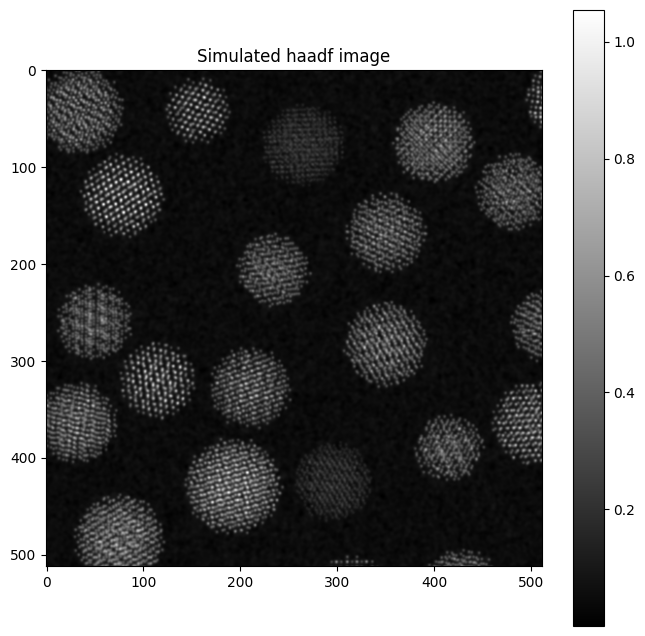

In [12]:
json_meta, raw_bytes = mic_proxy.get_scanned_image()
meta = json.loads(json_meta)
print(f"Metadata: {meta}")

image = np.frombuffer(raw_bytes, dtype=meta["dtype"]).reshape(meta["shape"])

plt.figure(figsize=(8, 8))
plt.imshow(image.T, cmap='gray')
plt.title(f"Simulated {meta['detector']} image")
plt.colorbar()
plt.show()

In [13]:
mic_proxy.place_beam([0.46, 0.65])

## Query beam

In [14]:
beam_pos = mic_proxy.beam_pos

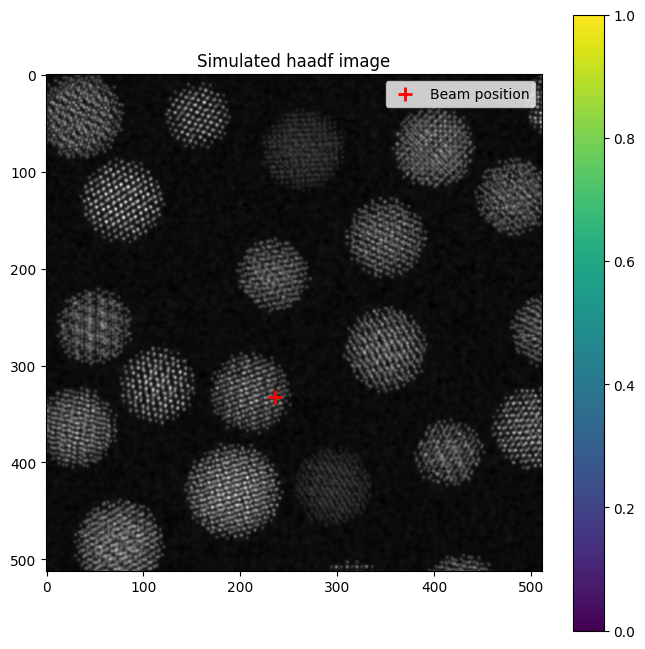

In [15]:
# Read beam position and scale from fractional [0,1] to pixel coordinates
beam_pos = mic_proxy.beam_pos                  # returns [x, y] in [0.0, 1.0]
h, w = image.shape
beam_x_px = beam_pos[0] * w                   # fractional → pixel
beam_y_px = beam_pos[1] * h

plt.figure(figsize=(8, 8))
plt.imshow(image.T, cmap='gray')

# Overlay beam position
plt.scatter(beam_x_px, beam_y_px, 
            color='red', s=100, marker='+',
            linewidths=2, label="Beam position")

plt.title(f"Simulated {meta['detector']} image")
plt.legend(loc='upper right')
plt.colorbar()
plt.show()

## EDS

In [16]:
json_meta, raw_bytes = mic_proxy.get_spectrum('eds')
metadata  = dict(json.loads(json_meta))
spectrum = dict(json.loads(raw_bytes))
spectrum

{'Au': 1.3200310427711088}